
## Segmentación de Imágenes Infrarrojas (IR)
### Selección de Área de Interés usando Filtros, Bordes y Morfología Matemática



## Objetivos
1. Seleccionar el área de interés (ROI).
2. Comparar dos técnicas independientes.
3. Aplicar un método secuencial.
4. Generar máscara binaria.
5. Evaluar métricas cuantitativas.


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (15,5)


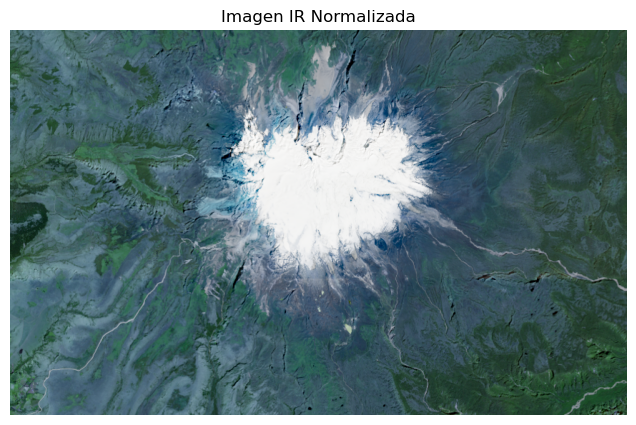

In [8]:

ruta =  r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\Data\cayambe.tif"

img = cv2.imread(ruta, cv2.IMREAD_UNCHANGED)

if img is None:
    raise ValueError("No se pudo cargar la imagen. Verifique la ruta.")

if len(img.shape) < 2:
    raise ValueError("Imagen inválida.")

img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.imshow(img_norm, cmap='gray')
plt.title("Imagen IR Normalizada")
plt.axis('off')
plt.show()


### Método 1: Verificar Filtro, Bordes y Morfología

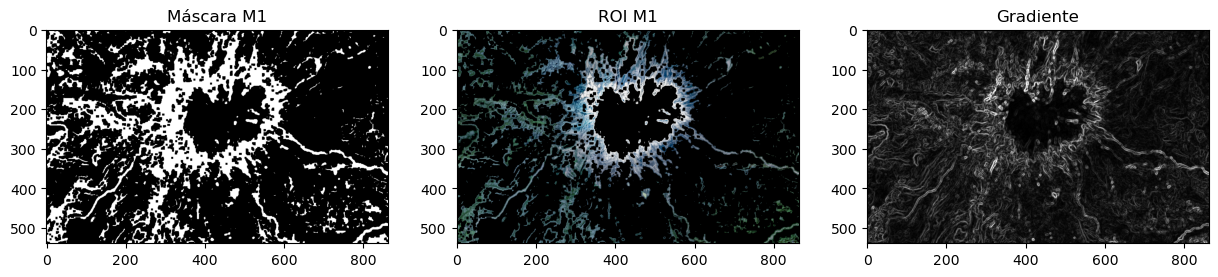

In [9]:

# Verificar si la imagen tiene 3 canales
if len(img_norm.shape) == 3:
    img_gray = cv2.cvtColor(img_norm, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img_norm.copy()

# Suavizado
blur = cv2.GaussianBlur(img_gray, (5,5), 0)

# Gradiente Sobel
sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
gradient = cv2.magnitude(sobelx, sobely)

# Convertir a 8 bits (IMPORTANTE)
gradient = cv2.convertScaleAbs(gradient)

# Asegurar 1 canal antes de Otsu
if len(gradient.shape) == 3:
    gradient = cv2.cvtColor(gradient, cv2.COLOR_BGR2GRAY)

# Umbralización Otsu
_, binary1 = cv2.threshold(
    gradient,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((5,5), np.uint8)
mask_morph = cv2.morphologyEx(binary1, cv2.MORPH_CLOSE, kernel)

roi_morph = cv2.bitwise_and(img_norm, img_norm, mask=mask_morph)

plt.subplot(1,3,1); plt.imshow(mask_morph, cmap='gray'); plt.title("Máscara M1")
plt.subplot(1,3,2); plt.imshow(roi_morph, cmap='gray'); plt.title("ROI M1")
plt.subplot(1,3,3); plt.imshow(gradient, cmap='gray'); plt.title("Gradiente")
plt.show()

### Método 2: Aplicando Watershed

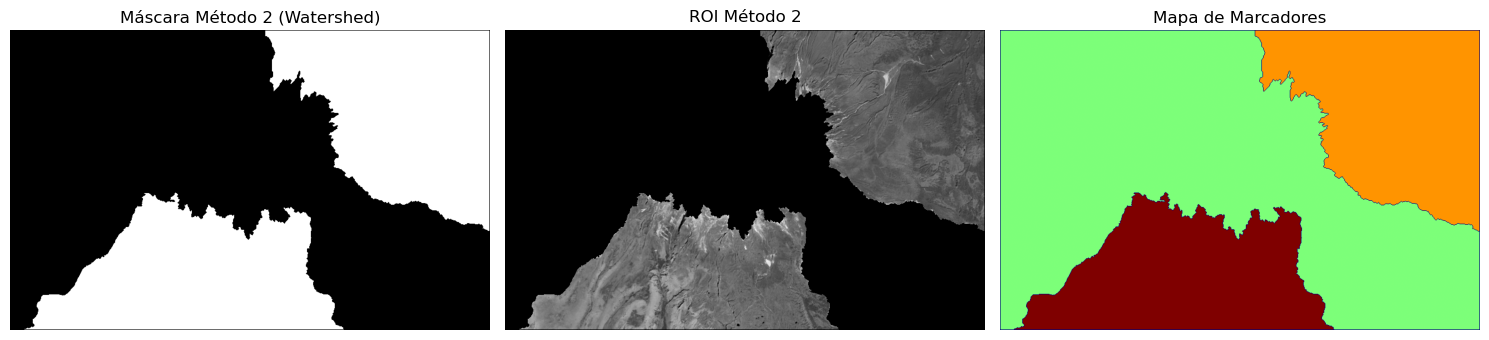

In [10]:
# ===============================
# VALIDACIÓN DE FORMATO DE IMAGEN
# ===============================

if img_norm is None:
    raise ValueError("Error: La imagen no se cargó correctamente.")

# Si tiene 3 canales, convertir a escala de grises
if len(img_norm.shape) == 3:
    img_gray = cv2.cvtColor(img_norm, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img_norm.copy()

# Asegurar que sea 8 bits
if img_gray.dtype != np.uint8:
    img_gray = cv2.normalize(img_gray, None, 0, 255,
                             cv2.NORM_MINMAX).astype(np.uint8)

# ===============================
# 1. UMBRALIZACIÓN (OTSU)
# ===============================

_, thresh = cv2.threshold(
    img_gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# ===============================
# 2. MORFOLOGÍA (Limpieza)
# ===============================

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

# Fondo seguro
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# ===============================
# 3. TRANSFORMADA DE DISTANCIA
# ===============================

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Umbral del foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Región desconocida
unknown = cv2.subtract(sure_bg, sure_fg)

# ===============================
# 4. MARCADORES
# ===============================

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# ===============================
# 5. WATERSHED
# ===============================

img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

markers = cv2.watershed(img_color, markers)

# ===============================
# 6. GENERACIÓN DE MÁSCARA
# ===============================

mask_ws = np.zeros(img_gray.shape, dtype=np.uint8)
mask_ws[markers > 1] = 255

roi_ws = cv2.bitwise_and(
    img_gray,
    img_gray,
    mask=mask_ws
)

# ===============================
# 7. VISUALIZACIÓN
# ===============================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(mask_ws, cmap='gray')
plt.title("Máscara Método 2 (Watershed)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(roi_ws, cmap='gray')
plt.title("ROI Método 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(markers, cmap='jet')
plt.title("Mapa de Marcadores")
plt.axis("off")

plt.tight_layout()
plt.show()

### Comparación entre el método 1 y método 2

In [11]:
def calcular_area(mask):
    return np.sum(mask == 255)

area_m1 = calcular_area(mask_morph)
area_m2 = calcular_area(mask_ws)

print("Área Método 1:", area_m1)
print("Área Método 2:", area_m2)
print("Diferencia porcentual:",
      abs(area_m1 - area_m2) / max(area_m1, area_m2) * 100, "%")

Área Método 1: 101070
Área Método 2: 187601
Diferencia porcentual: 46.12502065554022 %


## Método Secuencial

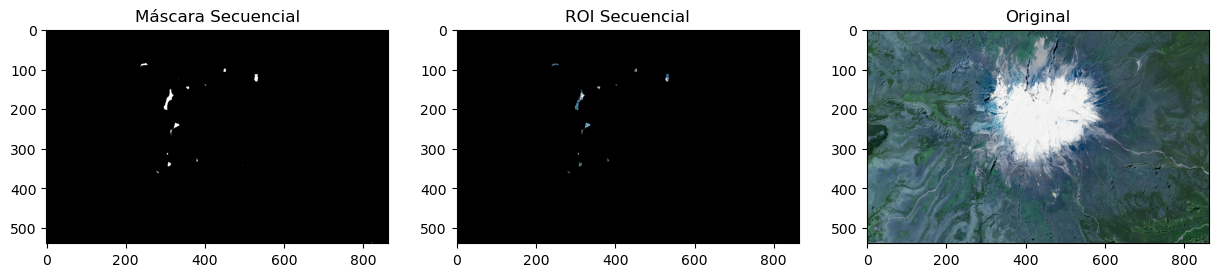

In [12]:

opening2 = cv2.morphologyEx(mask_morph, cv2.MORPH_OPEN, kernel)

dist_transform2 = cv2.distanceTransform(opening2, cv2.DIST_L2, 5)
_, sure_fg2 = cv2.threshold(dist_transform2, 0.7 * dist_transform2.max(), 255, 0)

sure_fg2 = np.uint8(sure_fg2)
_, markers2 = cv2.connectedComponents(sure_fg2)
markers2 = markers2 + 1

markers2 = cv2.watershed(img_color, markers2)

# Crear máscara correctamente (1 canal)
mask_seq = np.zeros(img_norm.shape[:2], dtype=np.uint8)
mask_seq[markers2 > 1] = 255

# Asegurar compatibilidad
if len(img_norm.shape) == 3:
    roi_seq = cv2.bitwise_and(img_norm, img_norm, mask=mask_seq)
else:
    roi_seq = cv2.bitwise_and(img_norm, img_norm, mask=mask_seq)

plt.subplot(1,3,1); plt.imshow(mask_seq, cmap='gray'); plt.title("Máscara Secuencial")
plt.subplot(1,3,2); plt.imshow(roi_seq, cmap='gray'); plt.title("ROI Secuencial")
plt.subplot(1,3,3); plt.imshow(img_norm, cmap='gray'); plt.title("Original")
plt.show()


## Métricas Cuantitativas

In [13]:

def area_segmentada(mask):
    return np.sum(mask > 0)

def porcentaje_roi(mask):
    return 100 * np.sum(mask > 0) / mask.size

print("Área Método 1:", area_segmentada(mask_morph))
print("Área Método 2:", area_segmentada(mask_ws))
print("Área Secuencial:", area_segmentada(mask_seq))

print("Porcentaje ROI M1: {:.2f}%".format(porcentaje_roi(mask_morph)))
print("Porcentaje ROI M2: {:.2f}%".format(porcentaje_roi(mask_ws)))
print("Porcentaje ROI Secuencial: {:.2f}%".format(porcentaje_roi(mask_seq)))


Área Método 1: 101070
Área Método 2: 187601
Área Secuencial: 947
Porcentaje ROI M1: 21.73%
Porcentaje ROI M2: 40.33%
Porcentaje ROI Secuencial: 0.20%


## Comparación Visual Final

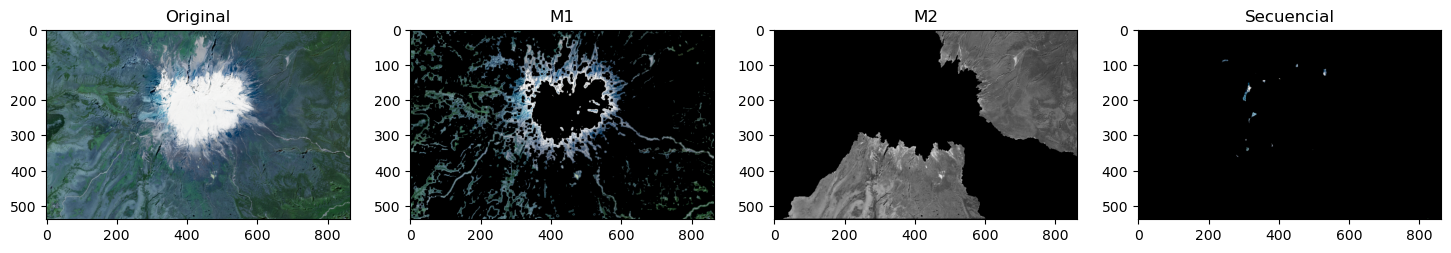

In [14]:

plt.figure(figsize=(18,6))
plt.subplot(1,4,1); plt.imshow(img_norm, cmap='gray'); plt.title("Original")
plt.subplot(1,4,2); plt.imshow(roi_morph, cmap='gray'); plt.title("M1")
plt.subplot(1,4,3); plt.imshow(roi_ws, cmap='gray'); plt.title("M2")
plt.subplot(1,4,4); plt.imshow(roi_seq, cmap='gray'); plt.title("Secuencial")
plt.show()


Una vez que haya podido elegir el área de interés, úselo como una máscara para aplicar el conjunto de prueba  (testset), donde solo se pueda observar el área de interés y el resto de pixeles estén asignado el valor de 0. 

Imágenes encontradas: 277


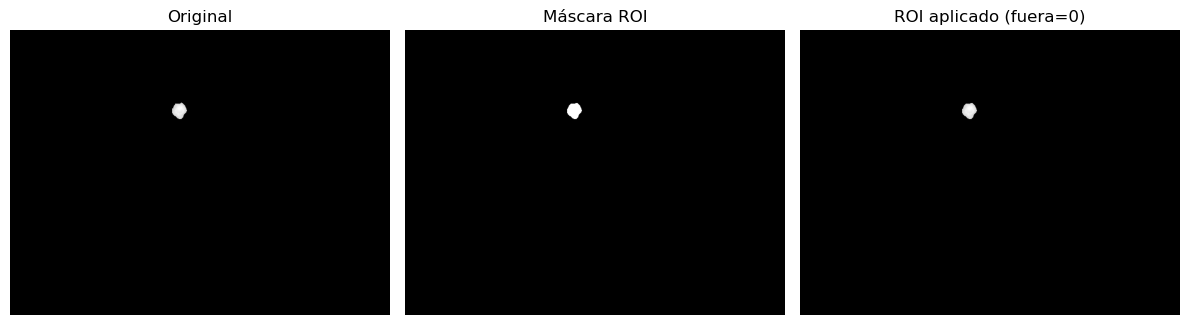

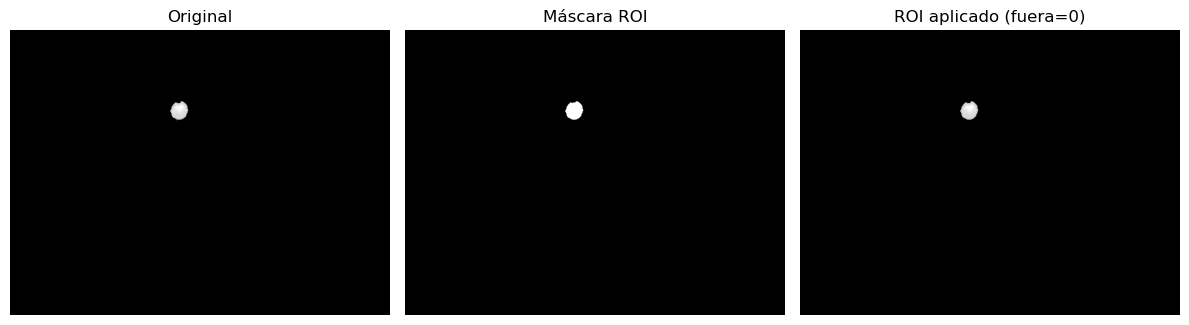

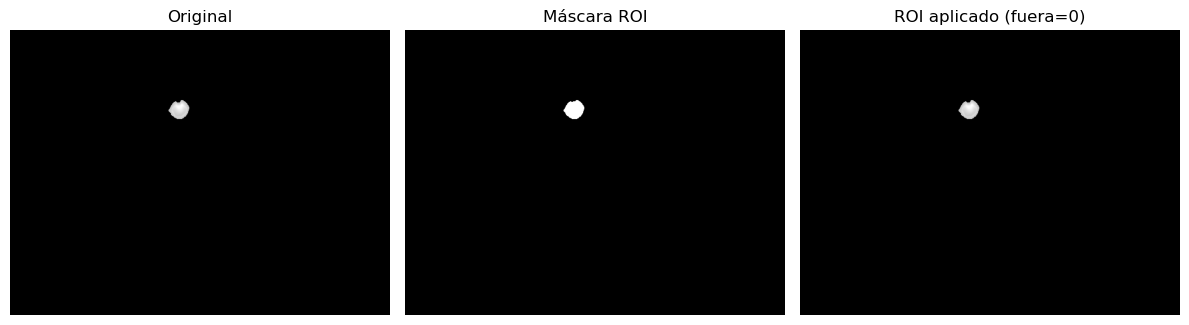

In [27]:

from glob import glob


BEST_MASK = mask_seq   # <- o mask_morph / mask_ws

# Asegurar que sea binaria 0/255
BEST_MASK = ((BEST_MASK > 0).astype(np.uint8)) * 255

TESTSET_FOLDER = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test"
OUT_FOLDER     = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test_masked"

paths = sorted(glob(os.path.join(TESTSET_FOLDER, "*.tif"))) 
print("Imágenes encontradas:", len(paths))

for i, p in enumerate(paths):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

    # ======= Generar ROI =======
    blur = cv2.GaussianBlur(img, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if (th > 0).mean() > 0.6:
        th = cv2.bitwise_not(th)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
    mask = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean = np.zeros_like(mask)
        clean[labels == largest] = 255
        mask = clean

    result = cv2.bitwise_and(img, img, mask=mask)

    cv2.imwrite(os.path.join(OUT_FOLDER, os.path.basename(p)), result)

    # ======= MOSTRAR IMÁGENES (solo primeras 3 para no saturar) =======
    if i < 3:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Máscara ROI")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(result, cmap='gray')
        plt.title("ROI aplicado (fuera=0)")
        plt.axis("off")

        plt.tight_layout()
        plt.show()